# Demand Forecasting with LSTM

Prophet handled the seasonal patterns 📅. Now we bring in deep learning to capture short-term momentum.

**We will:**
1. Scale & prepare weekly revenue data
2. Create sequences — use 8 past weeks to predict the next
3. Build an LSTM with PyTorch Lightning
4. Train & evaluate vs our Prophet baseline

**LSTM (Long Short-Term Memory)** is a neural network built for sequences:

- 🔁 Remembers patterns across many time steps
- 🧬 Learns complex non-linear relationships automatically
- 📈 Captures weekly/monthly retail rhythms without manual feature engineering

**Why LSTM for demand forecasting?**
- Better at short-term momentum than Prophet — if the last month surged, LSTM feels it
- No need to specify holidays or seasonality — it discovers patterns on its own
- Complements Prophet: Prophet nails the calendar, LSTM nails the velocity

In [32]:
# Loading libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import joblib
import pathlib
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
import mlflow

import warnings
warnings.filterwarnings('ignore')

# Setting random seed for reproducibility
pl.seed_everything(42)

Seed set to 42


42

## 1. Data Preparation & Scaling
Neural networks are highly sensitive to the scale of input data. We must scale our revenue down to a range between `(-1, 1)` or `(0, 1)` using `MinMaxScaler`.

In [33]:
# Loading pre-processed weekly revenue 
processed_dir = pathlib.Path.cwd().parent / 'data' / 'processed'
weekly_revenue = pd.read_csv(processed_dir / 'weekly_revenue.csv', parse_dates=['Date'])

# Isolate the target variable
data = weekly_revenue[['TotalPrice']].values.astype('float32')

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print(f"Total weeks of data: {len(data_scaled)}")

Total weeks of data: 106


## 2. Creating Sequences (Sliding Window)
To train an LSTM, we need to convert our single column of data into pairs of `(X, y)`.
- `X` will be a sequence of $N$ previous weeks.
- `y` will be the revenue of the $N+1$ week.

In [34]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [35]:
SEQUENCE_LENGTH = 8 # Use the past 8 weeks (2 months) to predict the next week
X, y = create_sequences(data_scaled, SEQUENCE_LENGTH)

In [36]:
# (batch_size, sequence_length, num_features)
print(f"X shape: {X.shape}") 
print(f"y shape: {y.shape}")

X shape: (98, 8, 1)
y shape: (98, 1)


### Train/Test Split & PyTorch DataLoaders
We split off the last 12 weeks for testing (just like in our Prophet model).

In [37]:
TEST_SIZE = 12

X_train, y_train = X[:-TEST_SIZE], y[:-TEST_SIZE]
X_test, y_test = X[-TEST_SIZE:], y[-TEST_SIZE:]

In [38]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [39]:
# PyTorch DataLoaders
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

## 3. PyTorch Lightning LSTM Module
We encapsulate our neural network architecture, training loop, and optimizer inside a clean `LightningModule`.

In [40]:
class LSTMForecaster(pl.LightningModule):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=1, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()
        
        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_dim, output_dim) # The Output fully-connected layer
        self.loss_fn = nn.MSELoss()
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm_out, (hn, cn) = self.lstm(x)
        last_time_step_out = lstm_out[:, -1, :]
        out = self.linear(last_time_step_out)
        return out
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

## 4. Training the Model and MLFlow Tracking
We use the PyTorch Lightning `Trainer` which abstracts away all the complex training loops.

In [41]:
# Initializing model
model = LSTMForecaster(hidden_dim=128, num_layers=2, learning_rate=0.005)

In [42]:
# Initializing trainer with MLflow logging
trainer = pl.Trainer(
    max_epochs=150, 
    enable_progress_bar=True, 
    enable_model_summary=False,
    logger=False,  # disable MLflow during training
    default_root_dir='../checkpoints' 
)
trainer.fit(model, train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


`Trainer.fit` stopped: `max_epochs=150` reached.


## 5. Forecasting & Evaluation
Now we pass our unseen Test Set through the trained network, inverse transform the scaled predictions back to actual Revenue (£), and calculate our error metrics.

In [43]:
model.eval()
predictions_scaled = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        y_hat = model(x_batch)
        predictions_scaled.append(y_hat.numpy().flatten()[0])

In [44]:
# Inverse transform the predictions and actuals back to original £ values
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1))
actuals = scaler.inverse_transform(y_test)

In [45]:
# MAPE
mape = np.mean(np.abs((actuals - predictions) / (actuals + 1e-9))) * 100
mean_revenue = actuals.mean()

print(f"--- LSTM Evaluation (12-Week Forecast) ---")
print(f"📊 MAPE: {mape:.2f}%")
print(f"📈 Average Weekly Revenue in Test Set: £{mean_revenue:,.2f}")

--- LSTM Evaluation (12-Week Forecast) ---
📊 MAPE: 22.09%
📈 Average Weekly Revenue in Test Set: £289,911.88


In [46]:
if mape < 10:
    print(f"✅ Excellent: MAPE of {mape:.2f}% indicates highly accurate weekly forecasts.")
elif mape < 20:
    print(f"✅ Good: MAPE of {mape:.2f}% is solid for retail forecasting.")
else:
    print(f"⚠️ Moderate: MAPE of {mape:.2f}% — deep learning helps but room for improvement.")

⚠️ Moderate: MAPE of 22.09% — deep learning helps but room for improvement.


### Plotting LSTM Predictions vs Actuals

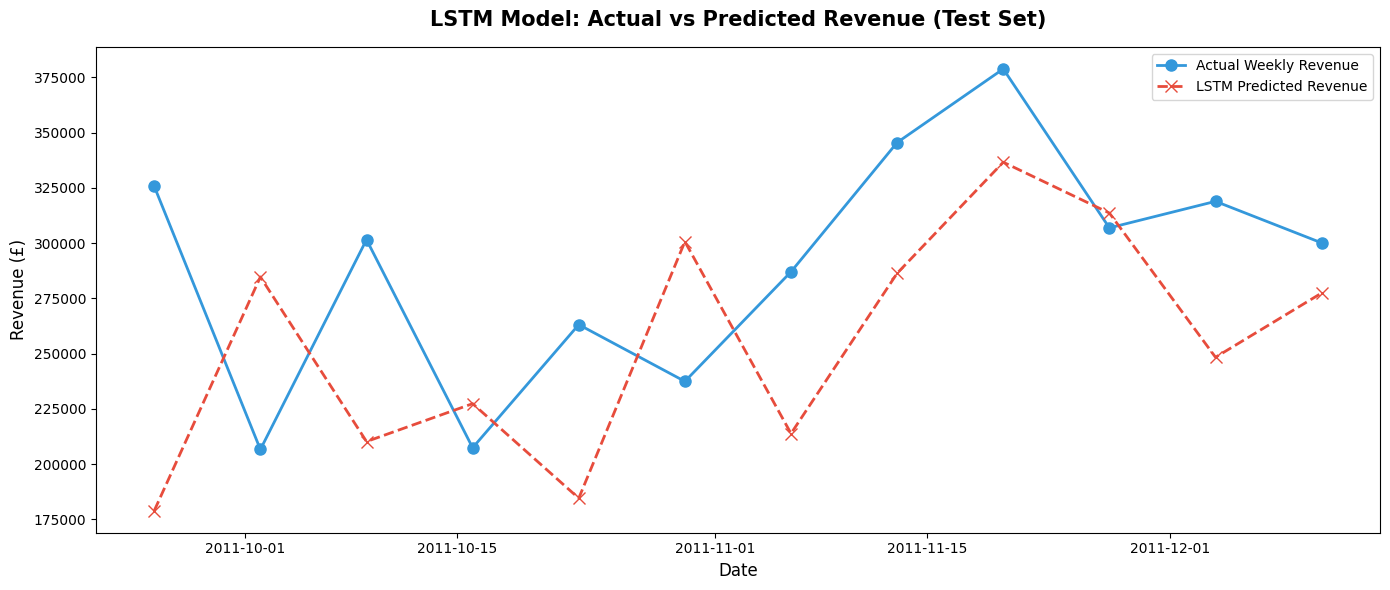

In [47]:
test_dates = weekly_revenue['Date'].iloc[-TEST_SIZE:].values

plt.figure(figsize=(14, 6))
plt.plot(test_dates, actuals, label='Actual Weekly Revenue', marker='o', 
         color='#3498db', linewidth=2, markersize=8)
plt.plot(test_dates, predictions, label='LSTM Predicted Revenue', marker='x', 
         color='#e74c3c', linestyle='--', linewidth=2, markersize=8)
plt.title('LSTM Model: Actual vs Predicted Revenue (Test Set)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Comparing LSTM vs Prophet:**
- **Prophet** is usually better at capturing hard macro-seasonality (like yearly holidays) out-of-the-box.
- **LSTM** is much better at understanding immediate short-term momentum (e.g., if the last 4 weeks were a massive bull run, the LSTM understands that immediate velocity better than Prophet).

## 6. Model & Metrics Persistence
We save the standalone LSTM model, the scaler, and the performance metrics.

In [48]:
os.makedirs('../models', exist_ok=True)

# LSTM Model State
torch.save(model.state_dict(), '../models/standalone_lstm_model_state.pt')

# Scaler
joblib.dump(scaler, '../models/standalone_lstm_scaler.joblib')

# Metrics
lstm_metrics = {
    'MAPE': round(float(mape), 2),
}

with open('../models/lstm_metrics.json', 'w') as f:
    json.dump(lstm_metrics, f, indent=4)
print("✅ LSTM model, scaler, and metrics saved to '../models/'.")

✅ LSTM model, scaler, and metrics saved to '../models/'.


## MLFlow Tracking

In [49]:
mlflow.set_tracking_uri(f"file:{pathlib.Path.cwd().parent / 'mlruns'}")
mlflow.set_experiment("RetailPulse_Demand_Forecasting")

with mlflow.start_run(run_name="LSTM_Weekly_Forecast"):
    mlflow.log_metric("LSTM_MAPE", float(mape))
    mlflow.log_param("sequence_length", SEQUENCE_LENGTH)
    mlflow.log_param("hidden_dim", 128)
    mlflow.log_param("epochs", 150)

print("✅ LSTM metrics logged to MLflow!")

✅ LSTM metrics logged to MLflow!
